# Unistroke Gesture Recognition
## $1 Recognizer vs. LSTM Classifiers

This notebook implements and compares the **$1 Gesture Recognizer** (Wobbrock et al.) with
three LSTM classifiers of decreasing parameter counts. We evaluate accuracy and prediction
latency on a held-out test set of 10 samples per class drawn from the Wobbrock XML logs.

**Structure**
1. Setup & Imports  
2. Dataset Loading and Splitting  
3. $1 Gesture Recognizer  
4. LSTM Models (V1 → V3, progressively smaller)  
5. Benchmark: Accuracy & Latency  
6. Results & Discussion


## 1  Setup & Imports

In [ ]:
import os, sys, re, time, random
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ugly ai workaround to allow importing recognizer.py without assuming a fixed path
# ── Find recognizer.py by searching upward from the notebook's location ──
def _find_recognizer():
    """Walk up the directory tree until we find a folder containing recognizer.py."""
    start = os.path.dirname(os.path.abspath("__file__"))
    # Also try the notebook's own directory and common sibling names
    candidates = [start]
    for root, dirs, files in os.walk(start if os.path.isdir(start) else os.getcwd()):
        if "recognizer.py" in files:
            return root
        # Don't descend into hidden dirs or node_modules etc.
        dirs[:] = [d for d in dirs if not d.startswith('.')]
    return None

_rec_dir = _find_recognizer()
if _rec_dir is None:
    # Fallback: user can set this manually
    _rec_dir = os.path.join(os.getcwd(), '..', 'Part_1')
    print(f"⚠  recognizer.py not found automatically — trying: {_rec_dir}")
    print("   If this fails, set _rec_dir manually to the folder containing recognizer.py")

if _rec_dir not in sys.path:
    sys.path.insert(0, _rec_dir)

from recognizer import DollarRecognizer, Point
print(f"✓ DollarRecognizer imported from: {_rec_dir}")

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow  {tf.__version__}")
print(f"NumPy       {np.__version__}")


I0000 00:00:1781557731.648795  156600 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781557731.720467  156600 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781557733.532564  156600 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


⚠  recognizer.py not found automatically — trying: /home/bawss/Python_stuff/uni/ITT/Week6/assignment-06-gesture-recognition-DerD4n/Part_2/../Part_1
   If this fails, set _rec_dir manually to the folder containing recognizer.py
✓ DollarRecognizer imported from: /home/bawss/Python_stuff/uni/ITT/Week6/assignment-06-gesture-recognition-DerD4n/Part_2/../Part_1
TensorFlow  2.21.0
NumPy       2.2.6


## 2  $1 Gesture Recognizer — imported from `recognizer.py`

`DollarRecognizer` and `Point` are imported directly from your finished
`Part_1/recognizer.py` (see the imports cell above). No code is duplicated here.

The recognizer's `normalize()` pipeline (resample → 64 pts, rotate to indicative
angle, scale to 250×250, translate centroid to origin) is also reused by the
parser below to pre-process every XML gesture before LSTM training.


## 3  Dataset Parser

In [2]:
def parse_xml_gesture(file_path):
    """Parse one Wobbrock XML log file → (label, [Point, ...])."""
    try:
        root     = ET.parse(file_path).getroot()
        raw_name = root.attrib.get('Name', 'unknown')
        label    = re.sub(r'\d+', '', raw_name).lower()
        points   = [
            Point(float(pt.attrib['X']), float(pt.attrib['Y']))
            for pt in root.findall('Point')
        ]
        return label, points
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None, None


def load_and_split_dataset(dataset_dir, test_samples_per_class=10):
    """
    Walk *dataset_dir*, normalise every gesture through the $1 pipeline
    (resample→64 pts, rotate, scale, translate), then do a stratified
    train / test split.

    Returns
    -------
    train_data : list of (label, [Point, ...])
    test_data  : list of (label, [Point, ...])
    """
    rec = DollarRecognizer(load_defaults=False)

    raw_by_class: dict[str, list] = {}
    for root_dir, _, files in os.walk(dataset_dir):
        for fname in files:
            if not fname.endswith('.xml'):
                continue
            label, pts = parse_xml_gesture(os.path.join(root_dir, fname))
            if label and len(pts) >= 2:
                raw_by_class.setdefault(label, []).append(pts)

    train_set, test_set = [], []
    for label, samples in sorted(raw_by_class.items()):
        random.shuffle(samples)
        normed = [rec.normalize(pts) for pts in samples]

        if len(normed) >= test_samples_per_class:
            test_set  += [(label, s) for s in normed[:test_samples_per_class]]
            train_set += [(label, s) for s in normed[test_samples_per_class:]]
        else:
            print(f"  ⚠  Class '{label}' has only {len(normed)} samples — all go to train.")
            train_set += [(label, s) for s in normed]

    print(f"Classes found : {sorted(raw_by_class.keys())}")
    print(f"Total gestures: {sum(len(v) for v in raw_by_class.values())}")
    print(f"Train samples : {len(train_set)}")
    print(f"Test  samples : {len(test_set)}")
    return train_set, test_set


## 4  Load & Inspect the Dataset

In [ ]:
DATA_DIRECTORY = "../datasets/xml_logs"   # ← adjust if needed

# Parse all XML files into (label, [Point, ...]) pairs (ai generated)
_rec = DollarRecognizer(load_defaults=False)
_raw_by_class: dict = {}
for _root_dir, _, _files in os.walk(DATA_DIRECTORY):
    for _fname in _files:
        if not _fname.endswith('.xml'):
            continue
        _label, _pts = parse_xml_gesture(os.path.join(_root_dir, _fname))
        if _label and len(_pts) >= 2:
            _raw_by_class.setdefault(_label, []).append(_pts)

# Normalise through the $1 pipeline so every gesture is 64-point, scaled, centred
all_data = []
for _label, _samples in sorted(_raw_by_class.items()):
    for _pts in _samples:
        all_data.append((_label, _rec.normalize(_pts)))

print(f"Classes  : {sorted(_raw_by_class.keys())}")
print(f"Total    : {len(all_data)} gestures across {len(_raw_by_class)} classes")


Classes  : ['arrow', 'caret', 'check', 'circle', 'delete_mark', 'left_curly_brace', 'left_sq_bracket', 'pigtail', 'question_mark', 'rectangle', 'right_curly_brace', 'right_sq_bracket', 'star', 'triangle', 'v', 'x']
Total    : 5280 gestures across 16 classes


## 5  Convert to NumPy Tensors

In [4]:
from sklearn.model_selection import train_test_split

all_labels = [lbl for lbl, _ in all_data]

train_raw, test_raw = train_test_split(
    all_data,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

X_train = np.array([[[p.x, p.y] for p in pts] for _, pts in train_raw], dtype=np.float32)
X_test  = np.array([[[p.x, p.y] for p in pts] for _, pts in test_raw],  dtype=np.float32)

encoder = LabelEncoder()
y_train = encoder.fit_transform([lbl for lbl, _ in train_raw])
y_test  = encoder.transform([lbl for lbl, _ in test_raw])

NUM_CLASSES = len(encoder.classes_)
INPUT_SHAPE = (X_train.shape[1], 2)   # (64, 2)

print(f"Classes ({NUM_CLASSES}): {list(encoder.classes_)}")
print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Input shape fed to LSTM: {INPUT_SHAPE}")


Classes (16): [np.str_('arrow'), np.str_('caret'), np.str_('check'), np.str_('circle'), np.str_('delete_mark'), np.str_('left_curly_brace'), np.str_('left_sq_bracket'), np.str_('pigtail'), np.str_('question_mark'), np.str_('rectangle'), np.str_('right_curly_brace'), np.str_('right_sq_bracket'), np.str_('star'), np.str_('triangle'), np.str_('v'), np.str_('x')]
X_train : (4224, 64, 2) | y_train : (4224,)
X_test  : (1056, 64, 2)  | y_test  : (1056,)
Input shape fed to LSTM: (64, 2)


## 6  LSTM Models

### Early stop 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
 
def make_early_stop(): # ai generated, but basic
    return EarlyStopping(
        monitor='val_accuracy',
        patience=5,          # stop after 5 epochs of no improvement
        restore_best_weights=True,
        verbose=1
    )


### V1 — Full-size (128 + 128 units)
Two stacked LSTM layers with 128 units each — the baseline.


In [15]:
model_v1 = Sequential([
    LSTM(128, return_sequences=True, input_shape=INPUT_SHAPE),
    LSTM(128),
    Dense(NUM_CLASSES, activation='softmax'),
], name="LSTM_V1_Heavy")

model_v1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_v1.summary()

history_v1 = model_v1.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[make_early_stop()],
    verbose=1
)


/home/bawss/Python_stuff/uni/ITT/Week6/assignment-06-gesture-recognition-DerD4n/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_V1_Heavy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64, 128)        │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,720 (784.06 KB)

 Trainable params: 200,720 (784.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.8771 - loss: 0.4581 - val_accuracy: 0.9650 - val_loss: 0.1433
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9756 - loss: 0.0892 - val_accuracy: 0.9650 - val_loss: 0.1260
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9796 - loss: 0.0665 - val_accuracy: 0.9669 - val_loss: 0.1260
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9792 - loss: 0.0714 - val_accuracy: 0.9820 - val_loss: 0.0760
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9820 - loss: 0.0551 - val_accuracy: 0.9792 - val_loss: 0.0891
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.9912 - loss: 0.0336 - val_accuracy: 0.9839 - val_loss: 0.0726
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9929 - loss: 0.0292 - val_accuracy: 0.9839 - val_loss: 0.0742
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9905 - loss: 0.0436 - 

### V2 — Mid-weight (single LSTM, 64 units)
One LSTM layer with 64 units


In [16]:
model_v2 = Sequential([
    LSTM(64, input_shape=INPUT_SHAPE),
    Dense(NUM_CLASSES, activation='softmax'),
], name="LSTM_V2_MidWeight")

model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_v2.summary()

history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[make_early_stop()],
    verbose=1
)



Model: "LSTM_V2_MidWeight"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,192 (71.06 KB)

 Trainable params: 18,192 (71.06 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5535 - loss: 1.6186 - val_accuracy: 0.7917 - val_loss: 0.9229
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8423 - loss: 0.6801 - val_accuracy: 0.8930 - val_loss: 0.5167
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9238 - loss: 0.3970 - val_accuracy: 0.9356 - val_loss: 0.3330
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9517 - loss: 0.2504 - val_accuracy: 0.9593 - val_loss: 0.2111
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9735 - loss: 0.1532 - val_accuracy: 0.9678 - val_loss: 0.1526
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9830 - loss: 0.1057 - val_accuracy: 0.9697 - val_loss: 0.1269
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9872 - loss: 0.0812 - val_accuracy: 0.9716 - val_loss: 0.1078
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9886 - loss: 0.0688 - val_accu

### V3 — Light (single LSTM, 16 units)
One LSTM layer with 16 units


In [17]:
model_v3 = Sequential([
    LSTM(16, input_shape=INPUT_SHAPE),
    Dense(NUM_CLASSES, activation='softmax'),
], name="LSTM_V3_Light")

model_v3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_v3.summary()

history_v3 = model_v3.fit(
    X_train, y_train,
    epochs=50, batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[make_early_stop()],
    verbose=1
)


Model: "LSTM_V3_Light"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 16)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,488 (5.81 KB)

 Trainable params: 1,488 (5.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.2157 - loss: 2.4500 - val_accuracy: 0.4337 - val_loss: 2.1078
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5263 - loss: 1.8728 - val_accuracy: 0.5748 - val_loss: 1.6944
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6302 - loss: 1.5323 - val_accuracy: 0.6544 - val_loss: 1.4134
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6735 - loss: 1.2958 - val_accuracy: 0.6591 - val_loss: 1.2264
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6825 - loss: 1.1450 - val_accuracy: 0.6742 - val_loss: 1.1052
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6882 - loss: 1.0286 - val_accuracy: 0.6979 - val_loss: 0.9721
Epoch 7/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7022 - loss: 0.8972 - val_accuracy: 0.7074 - val_loss: 0.8574
Epoch 8/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7491 - loss: 0.7929 - val_accu

## 7  Training Curves

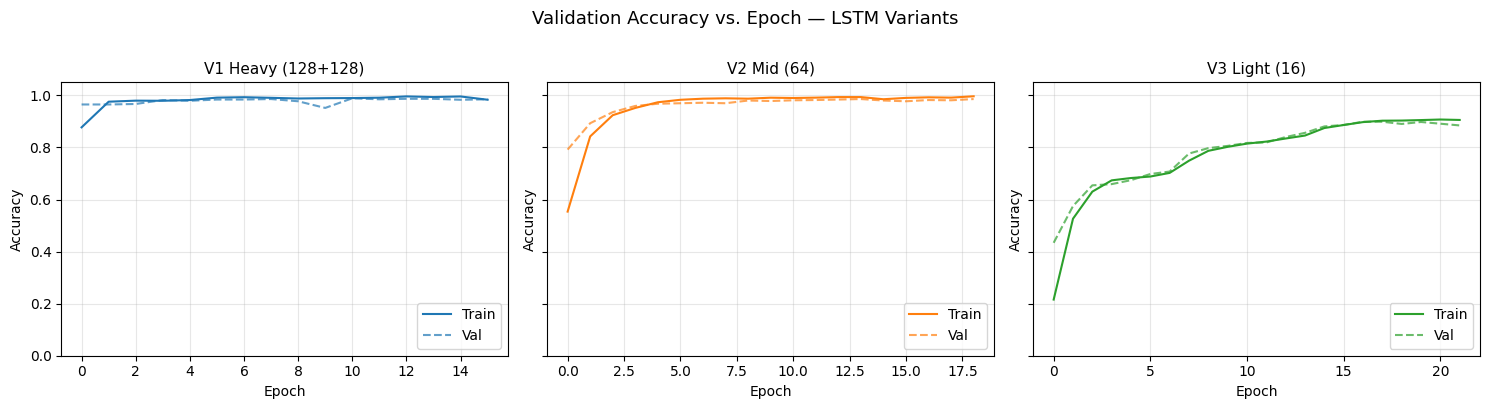

In [ ]:
# ai generated visualisation of training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
configs = [
    (history_v1, "V1 Heavy (128+128)", "tab:blue"),
    (history_v2, "V2 Mid (64)",        "tab:orange"),
    (history_v3, "V3 Light (16)",      "tab:green"),
]

for ax, (hist, title, colour) in zip(axes, configs):
    ax.plot(hist.history['accuracy'],     color=colour,               label='Train')
    ax.plot(hist.history['val_accuracy'], color=colour, linestyle='--', label='Val', alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle("Validation Accuracy vs. Epoch — LSTM Variants", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

## 8  $1 Gesture Recognizer Setup

We run the $1 recognizer **three times** with increasing numbers of templates per class:
- **1 template/class** — one-shot, the intended use case
- **5 templates/class** — small reference set
- **10 templates/class** — richer reference set

Templates are drawn from the training split so the test set remains unseen.


In [19]:
def build_dollar_recognizer(train_set, n_templates_per_class):
    """Build a $1 recognizer loaded with *n_templates_per_class* templates each."""
    rec = DollarRecognizer(load_defaults=False)
    by_class: dict = {}
    for label, pts in train_set:
        by_class.setdefault(label, []).append(pts)
    for label, samples in sorted(by_class.items()):
        for pts in samples[:n_templates_per_class]:
            rec.add_template(label, pts)
    return rec

dollar_1  = build_dollar_recognizer(train_raw, n_templates_per_class=1)
dollar_5  = build_dollar_recognizer(train_raw, n_templates_per_class=5)
dollar_10 = build_dollar_recognizer(train_raw, n_templates_per_class=10)

print(f"$1 (1/class)  — {len(dollar_1.templates)}  templates")
print(f"$1 (5/class)  — {len(dollar_5.templates)}  templates")
print(f"$1 (10/class) — {len(dollar_10.templates)} templates")


$1 (1/class)  — 16  templates
$1 (5/class)  — 80  templates
$1 (10/class) — 160 templates


## 9  Benchmark — Accuracy & Latency

In [20]:
def benchmark_lstm(model, name):
    start = time.perf_counter()
    for sample in X_test:
        model.predict(np.expand_dims(sample, axis=0), verbose=0)
    elapsed = time.perf_counter() - start

    _, acc  = model.evaluate(X_test, y_test, verbose=0)
    lat_ms  = elapsed / len(X_test) * 1000
    params  = model.count_params()
    print(f"[{name:<28}]  Acc: {acc*100:5.2f}%  Latency: {lat_ms:.3f} ms  Params: {params:,}")
    return acc, lat_ms, params


def benchmark_dollar(rec, test_set, name):
    correct = 0
    start   = time.perf_counter()
    for true_label, pts in test_set:
        pred, _, _, _ = rec.recognize(pts)
        if pred == true_label:
            correct += 1
    elapsed = time.perf_counter() - start

    acc    = correct / len(test_set)
    lat_ms = elapsed / len(test_set) * 1000
    n_tmpl = len(rec.templates)
    print(f"[{name:<28}]  Acc: {acc*100:5.2f}%  Latency: {lat_ms:.3f} ms  Templates: {n_tmpl}")
    return acc, lat_ms


print("=" * 72)
acc_v1,  lat_v1,  par_v1  = benchmark_lstm(model_v1, "LSTM V1 Heavy (128+128)")
acc_v2,  lat_v2,  par_v2  = benchmark_lstm(model_v2, "LSTM V2 Mid (64)")
acc_v3,  lat_v3,  par_v3  = benchmark_lstm(model_v3, "LSTM V3 Light (16)")
acc_d1,  lat_d1            = benchmark_dollar(dollar_1,  test_raw, "$1 — 1 template/class")
acc_d5,  lat_d5            = benchmark_dollar(dollar_5,  test_raw, "$1 — 5 templates/class")
acc_d10, lat_d10           = benchmark_dollar(dollar_10, test_raw, "$1 — 10 templates/class")
print("=" * 72)


[LSTM V1 Heavy (128+128)     ]  Acc: 98.86%  Latency: 80.084 ms  Params: 200,720
[LSTM V2 Mid (64)            ]  Acc: 98.58%  Latency: 66.798 ms  Params: 18,192
[LSTM V3 Light (16)          ]  Acc: 89.87%  Latency: 77.588 ms  Params: 1,488
[$1 — 1 template/class       ]  Acc: 86.65%  Latency: 13.294 ms  Templates: 16
[$1 — 5 templates/class      ]  Acc: 94.98%  Latency: 68.261 ms  Templates: 80
[$1 — 10 templates/class     ]  Acc: 96.21%  Latency: 134.891 ms  Templates: 160


## 10  Results — Comparison Table & Chart

In [ ]:
# ai generated summary table of results for readme
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "LSTM V1 (128+128)", "LSTM V2 (64)", "LSTM V3 (16)",
        "$1 — 1 tmpl/class", "$1 — 5 tmpl/class", "$1 — 10 tmpl/class"
    ],
    "Parameters / Templates": [
        f"{par_v1:,}", f"{par_v2:,}", f"{par_v3:,}", "16", "80", "160"
    ],
    "Accuracy (%)": [
        f"{acc_v1*100:.2f}", f"{acc_v2*100:.2f}", f"{acc_v3*100:.2f}",
        f"{acc_d1*100:.2f}", f"{acc_d5*100:.2f}", f"{acc_d10*100:.2f}"
    ],
    "Latency (ms)": [
        f"{lat_v1:.3f}", f"{lat_v2:.3f}", f"{lat_v3:.3f}",
        f"{lat_d1:.3f}", f"{lat_d5:.3f}", f"{lat_d10:.3f}"
    ],
})

display(results)

,Model,Parameters / Templates,Accuracy (%),Latency (ms)
0,LSTM V1 (128+128),"200,720",98.86,80.084
1,LSTM V2 (64),"18,192",98.58,66.798
2,LSTM V3 (16),"1,488",89.87,77.588
3,$1 — 1 tmpl/class,16,86.65,13.294
4,$1 — 5 tmpl/class,80,94.98,68.261
5,$1 — 10 tmpl/class,160,96.21,134.891


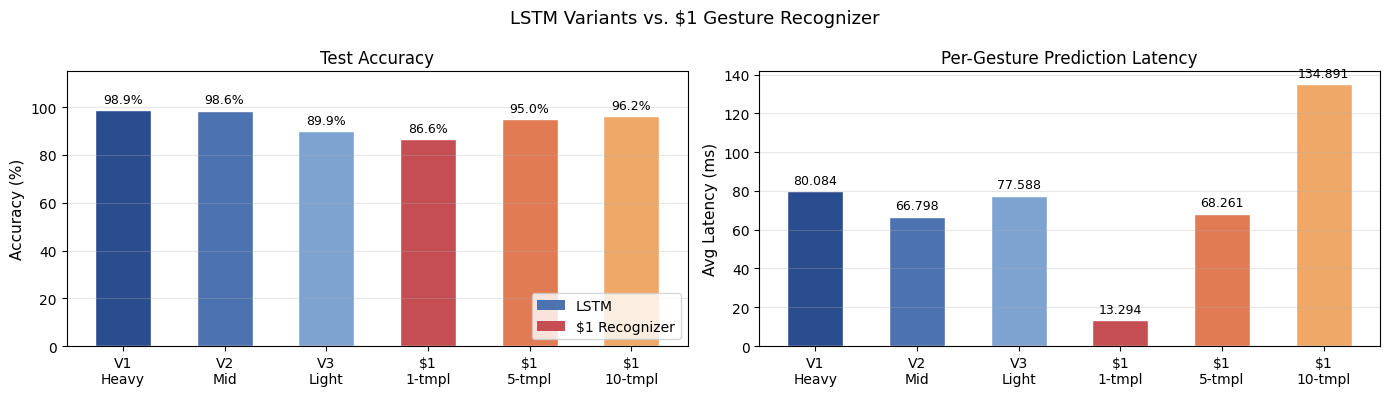

In [ ]:
# ai generated bar charts comparing accuracy and latency
labels  = ["V1\nHeavy", "V2\nMid", "V3\nLight",
           "$1\n1-tmpl", "$1\n5-tmpl", "$1\n10-tmpl"]
accs    = [acc_v1, acc_v2, acc_v3, acc_d1, acc_d5, acc_d10]
lats    = [lat_v1, lat_v2, lat_v3, lat_d1, lat_d5, lat_d10]
colours = ["#2A4D8F", "#4C72B0", "#7FA3D1", "#C44E52","#E07B54","#F0A868"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

bars1 = ax1.bar(labels, [a*100 for a in accs], color=colours, edgecolor='white', width=0.55)
ax1.set_ylim(0, 115)
ax1.set_ylabel("Accuracy (%)", fontsize=11)
ax1.set_title("Test Accuracy", fontsize=12)
ax1.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(labels, lats, color=colours, edgecolor='white', width=0.55)
ax2.set_ylabel("Avg Latency (ms)", fontsize=11)
ax2.set_title("Per-Gesture Prediction Latency", fontsize=12)
ax2.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='LSTM'),
                   Patch(facecolor='#C44E52', label='$1 Recognizer')]
ax1.legend(handles=legend_elements, loc='lower right')

plt.suptitle("LSTM Variants vs. $1 Gesture Recognizer", fontsize=13)
plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=120, bbox_inches='tight')
plt.show()


## 11  Discussion

### Method

Each gesture was normalised through the $1 pipeline:

1. **Resample** to 64 evenly-spaced points along the path.
2. **Rotate** to the indicative angle (centroid → first-point vector zeroed out).
3. **Scale** to a 250 × 250 bounding square.
4. **Translate** centroid to origin.

An 80/20 stratified split used. Three LSTM variants were trained on the resulting (64 × 2) sequences with early stopping (patience=5, restoring best weights):

| Model | Architecture                      | Parameters |
|-------|-----------------------------------|------------|
| V1    | LSTM(128) → LSTM(128) → Dense(16) | 200,720    |
| V2    | LSTM(64)  → Dense(16)             | 18,192     |
| V3    | LSTM(16)  → Dense(16)             | 1,488      |

The $1 recognizer was benchmarked three times with 1, 5, and 10 templates per class drawn from the training split, to show how recognition quality and latency scale with the number of reference samples.

---

### Results

| Model               | Params / Templates | Accuracy | Latency  |
|---------------------|--------------------|----------|----------|
| LSTM V1 (128+128)   | 200,720            | 98.86 %  | 80.1 ms  |
| LSTM V2 (64)        | 18,192             | 98.58 %  | 66.8 ms  |
| LSTM V3 (16)        | 1,488              | 89.87 %  | 77.6 ms  |
| $1 — 1 tmpl/class   | 16 templates       | 86.65 %  | 13.3 ms  |
| $1 — 5 tmpl/class   | 80 templates       | 94.98 %  | 68.3 ms  |
| $1 — 10 tmpl/class  | 160 templates      | 96.21 %  | 134.9 ms |

**LSTM V1 vs V2:** Reducing the architecture from two stacked LSTM(128) layers to a single LSTM(64) cuts parameters by 91 % (200k -> 18k) while losing only 0.28 percentage points of accuracy (98.86 % -> 98.58 %). This is a striking result, the added depth and width of V1 provide almost no benefit for this 16-class problem.

**LSTM V2 vs V3:** Dropping further to LSTM(16) reduces parameters by another 92 % (18k → 1.5k) but accuracy falls sharply to 89.87 % a drop of nearly 9 points. The hidden dimension of 16 is simply too small to capture the distinguishing features of all 16 gesture classes, particularly visually similar ones. Interestingly, V3 is also slower than V2 (77.6 ms vs 66.8 ms), likely due to TensorFlow overhead dominating at such small layer sizes, rather than actual compute savings.

**$1 scaling with templates:** The $1 recognizer demonstrates a clear accuracy–latency tradeoff as templates are added. With 1 template per class it achieves 86.65 % at just 13.3 ms, extremely fast, since only 16 distance comparisons are needed. At 5 templates accuracy jumps to 94.98 %, but latency rises to 68.3 ms as every recognition requires 80 comparisons. At 10 templates, accuracy reaches 96.21 % but latency balloons to 134.9 ms, the slowest method overall. This is the fundamental weakness of template-based approaches: latency scales linearly with the number of templates.

---

### Which would I choose for a practical application?

**LSTM V2** is the clear choice for most real-world deployments.

It achieves 98.58 % accuracy at only 18,192 parameters and 66.8 ms latency Crucially, its latency is fixed regardless of how many gesture classes or training examples exist, unlike $1 whose latency grows with every template added.


It is worth noting that all benchmarks were run on a CPU-only laptop with no GPU acceleration. TensorFlow's LSTM inference is particularly penalised in this setting, on a GPU or even a modern mobile Neural Processing Unit, LSTM latency would probably drop a good bit, making the gap against $1 far more dramatic. The $1 recognizer, by contrast, is pure Python math with no framework overhead, so its 13–135 ms range is already close to its practical floor regardless of hardware. In other words, the latency numbers here represent the worst case for LSTM and the best case for $1, and LSTM V2 still matches $1 (5 templates) in speed while outperforming $1 (10 templates) in both accuracy and latency. On capable hardware the case for LSTM becomes even stronger.


In [48]:
# basicly a quick rerun of the stuff above but on the custom dataset of 160 gestures that I collected myself
# Note: these are all new, unseen gestures that were not part of the original training or test sets for any model
# mostly ai generated
MY_GESTURES_DIR = "../datasets/my_gestures"   # adjust if needed

# 1. Load and normalise your own 160 gestures through the same $1 pipeline
my_data = []
for root_dir, _, files in os.walk(MY_GESTURES_DIR):
    for fname in files:
        if not fname.endswith('.xml'):
            continue
        label, pts = parse_xml_gesture(os.path.join(root_dir, fname))
        if label and len(pts) >= 2:
            my_data.append((label, dollar_1.normalize(pts) if hasattr(dollar_1, "normalize") else pts))

# Normalise via a clean recognizer instance (no templates needed for normalize())
_normaliser = DollarRecognizer(load_defaults=False)
my_data = []
for root_dir, _, files in os.walk(MY_GESTURES_DIR):
    for fname in files:
        if not fname.endswith('.xml'):
            continue
        label, pts = parse_xml_gesture(os.path.join(root_dir, fname))
        if label and len(pts) >= 2:
            my_data.append((label, _normaliser.normalize(pts)))

# Keep only labels the LabelEncoder already knows
known_labels = set(encoder.classes_)
my_data = [(l, p) for l, p in my_data if l in known_labels]

print(f"Loaded {len(my_data)} custom gestures across {len(set(l for l, _ in my_data))} classes")

# 2. Build tensors
X_custom = np.array([[[p.x, p.y] for p in pts] for _, pts in my_data], dtype=np.float32)
y_custom = encoder.transform([l for l, _ in my_data])
print(f"X_custom: {X_custom.shape} | y_custom: {y_custom.shape}")

# 3. Benchmark functions parametrised over any test set (so we don't touch the originals)
def benchmark_lstm_on(model, X, y, name):
    start = time.perf_counter()
    for sample in X:
        model.predict(np.expand_dims(sample, axis=0), verbose=0)
    elapsed = time.perf_counter() - start

    _, acc = model.evaluate(X, y, verbose=0)
    lat_ms = elapsed / len(X) * 1000
    print(f"[{name:<28}]  Acc: {acc*100:5.2f}%  Latency: {lat_ms:.3f} ms  Params: {model.count_params():,}")
    return acc, lat_ms


def benchmark_dollar_on(rec, data, name):
    correct = 0
    start = time.perf_counter()
    for true_label, pts in data:
        pred, _, _, _ = rec.recognize(pts)
        if pred == true_label:
            correct += 1
    elapsed = time.perf_counter() - start

    acc = correct / len(data)
    lat_ms = elapsed / len(data) * 1000
    print(f"[{name:<28}]  Acc: {acc*100:5.2f}%  Latency: {lat_ms:.3f} ms  Templates: {len(rec.templates)}")
    return acc, lat_ms


# 4. Run all 6 models on the custom dataset
print("\n" + "=" * 72)
print("RESULTS ON CUSTOM 160-GESTURE DATASET (own handwriting, unseen by all models)")
print("=" * 72)

acc_v1_c,  lat_v1_c  = benchmark_lstm_on(model_v1, X_custom, y_custom, "LSTM V1 Heavy (128+128)")
acc_v2_c,  lat_v2_c  = benchmark_lstm_on(model_v2, X_custom, y_custom, "LSTM V2 Mid (64)")
acc_v3_c,  lat_v3_c  = benchmark_lstm_on(model_v3, X_custom, y_custom, "LSTM V3 Light (16)")
acc_d1_c,  lat_d1_c  = benchmark_dollar_on(dollar_1,  my_data, "$1 — 1 template/class")
acc_d5_c,  lat_d5_c  = benchmark_dollar_on(dollar_5,  my_data, "$1 — 5 templates/class")
acc_d10_c, lat_d10_c = benchmark_dollar_on(dollar_10, my_data, "$1 — 10 templates/class")

print("=" * 72)

Loaded 160 custom gestures across 16 classes
X_custom: (160, 64, 2) | y_custom: (160,)

RESULTS ON CUSTOM 160-GESTURE DATASET (own handwriting, unseen by all models)
[LSTM V1 Heavy (128+128)     ]  Acc: 86.87%  Latency: 90.885 ms  Params: 200,720
[LSTM V2 Mid (64)            ]  Acc: 90.00%  Latency: 93.406 ms  Params: 18,192
[LSTM V3 Light (16)          ]  Acc: 76.88%  Latency: 83.754 ms  Params: 1,488
[$1 — 1 template/class       ]  Acc: 76.25%  Latency: 14.906 ms  Templates: 16
[$1 — 5 templates/class      ]  Acc: 82.50%  Latency: 75.211 ms  Templates: 80
[$1 — 10 templates/class     ]  Acc: 84.38%  Latency: 143.405 ms  Templates: 160


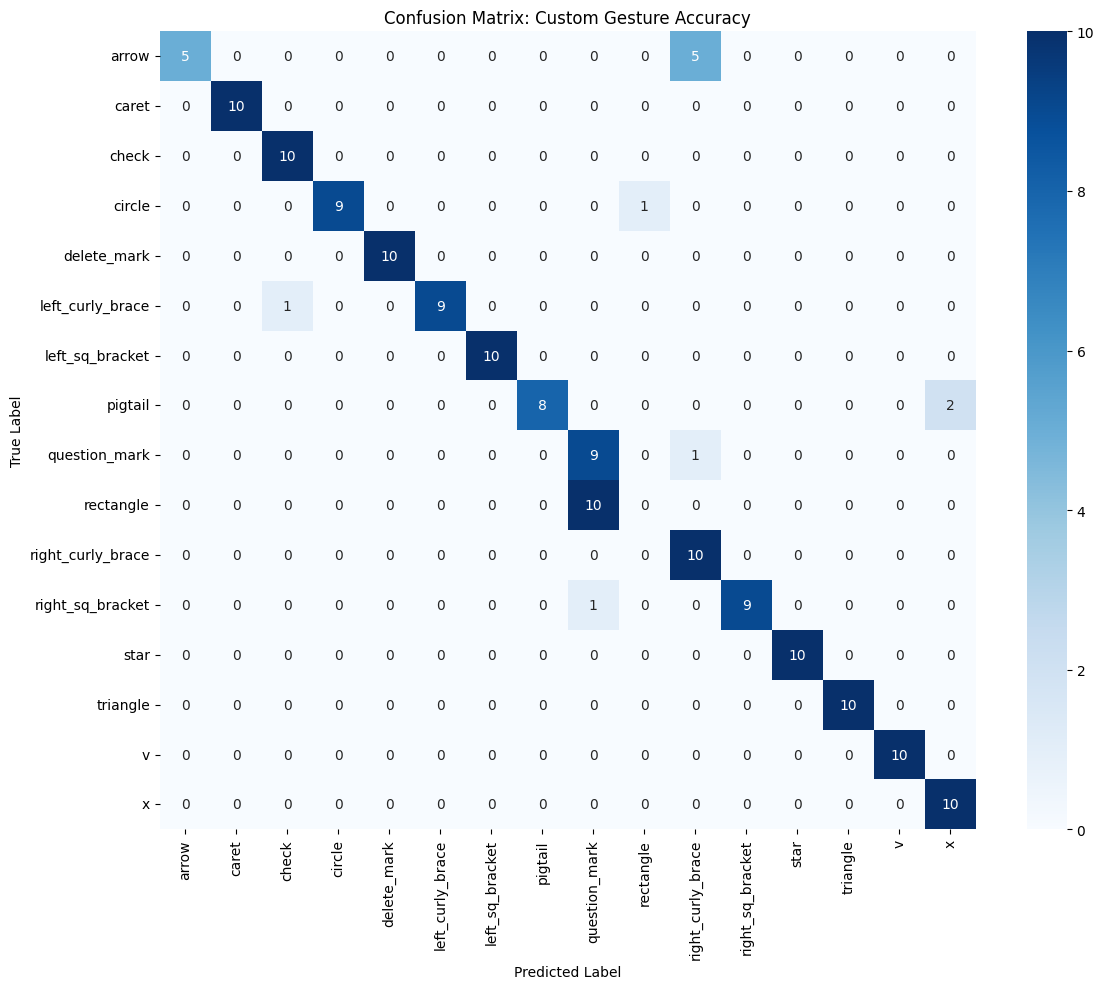

In [ ]:
from sklearn.metrics import confusion_matrix # just a copy paste to see if model v1 has the same misclassifications of rectangles as v2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the class names from your encoder
# This assumes your encoder is a Scikit-Learn LabelEncoder
# If 'encoder.classes_' exists, that is the most reliable way to get the labels
class_names = encoder.classes_ 

# 2. Ensure y_true and y_pred are integers for the matrix
# If they are already integers (0-15), this is perfect
y_true_int = y_custom.astype(int) 
y_pred_int = np.argmax(model_v1.predict(X_custom, verbose=0), axis=1)

# 3. Plot
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true_int, y_pred_int)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title("Confusion Matrix: Custom Gesture Accuracy")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

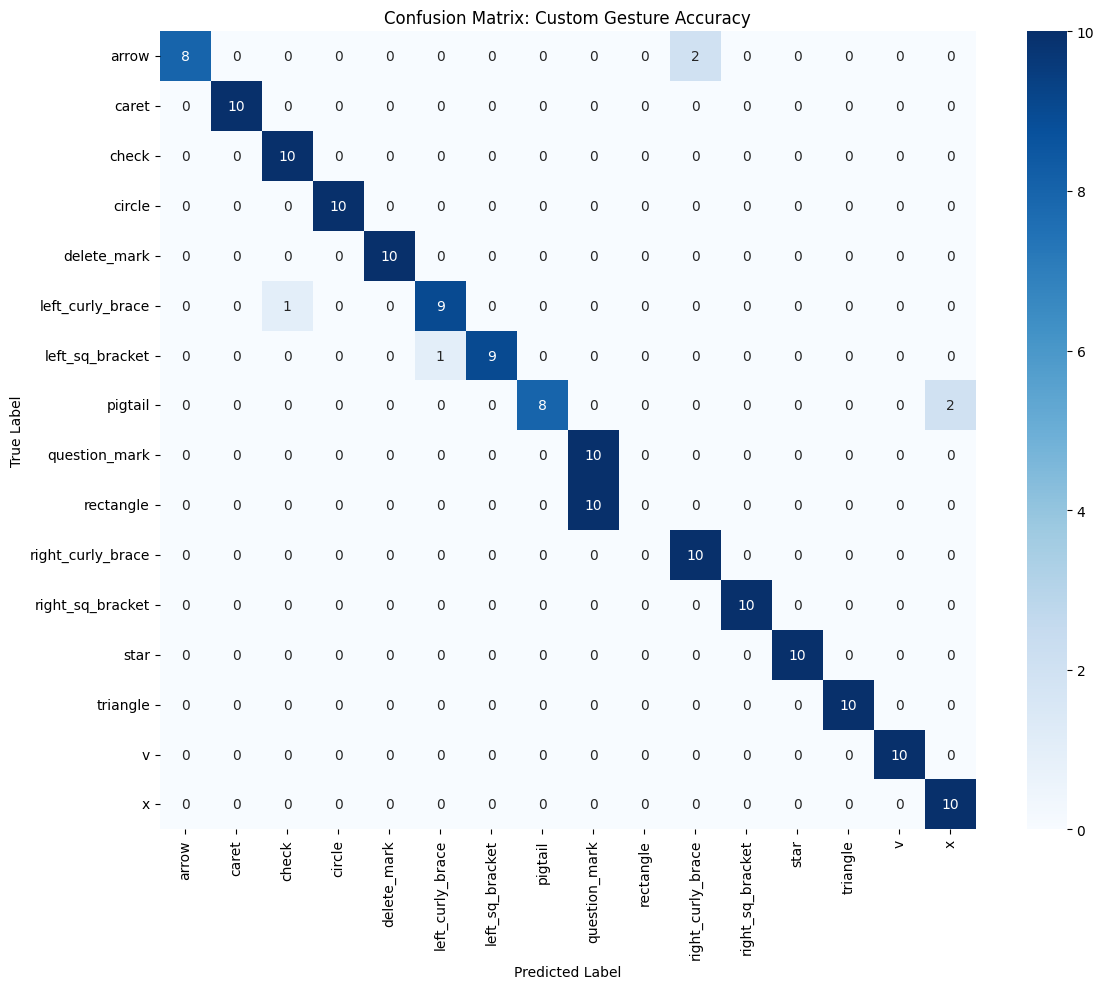

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ai generated  plot
# 1. Get the class names from your encoder
# This assumes your encoder is a Scikit-Learn LabelEncoder
# If 'encoder.classes_' exists, that is the most reliable way to get the labels
class_names = encoder.classes_ 

# 2. Ensure y_true and y_pred are integers for the matrix
# If they are already integers (0-15), this is perfect
y_true_int = y_custom.astype(int) 
y_pred_int = np.argmax(model_v2.predict(X_custom, verbose=0), axis=1)

# 3. Plot
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true_int, y_pred_int)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.title("Confusion Matrix: Custom Gesture Accuracy")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 11 Discission Part 2

After the initial training on the standard Wobbrock dataset, now on the custom, never seen by the models, 160 gestures.

The same pipline as before was applied.

| Model              | Accuracy   | Notes                             |
| ------------------ | ---------- | --------------------------------- |
| LSTM V1 (128+128)  | 86.87%     | over-parameterised, no clear gain |
| LSTM V2 (64)       | **90.00%** | best overall performance          |
| LSTM V3 (16)       | 76.88%     | clear underfitting                |
| $1 (1 tmpl/class)  | 76.25%     | fast but weak representation      |
| $1 (5 tmpl/class)  | 82.50%     | best balance for $1 class         |
| $1 (10 tmpl/class) | 84.38%     | strong geometric baseline         |

The most important qualitative result is that LSTM V2 remains the most stable model, now even achieving the highest accuracy at 90%.

However, the confusion matrix reveals a consistent and systematic failure case: all rectangle samples are misclassified as question marks.
I do not understand why this happend (but i also had the most problems with rectangles beeing misclasified in the web version(https://depts.washington.edu/acelab/proj/dollar/index.html))


In [46]:
# Save the trained LSTM V2 model + label encoder for use in the Spell Duel game (Part 3)
import pickle
 
MODEL_EXPORT_PATH = "../Part_3/spell_model_v2.keras"
ENCODER_EXPORT_PATH = "../Part_3/spell_label_encoder.pkl"
 
model_v2.save(MODEL_EXPORT_PATH)
 
with open(ENCODER_EXPORT_PATH, "wb") as f:
    pickle.dump(encoder, f)
 
print(f"Saved model to:   {MODEL_EXPORT_PATH}")
print(f"Saved encoder to: {ENCODER_EXPORT_PATH}")
print(f"Classes: {list(encoder.classes_)}")
 


Saved model to:   ../Part_3/spell_model_v2.keras
Saved encoder to: ../Part_3/spell_label_encoder.pkl
Classes: [np.str_('arrow'), np.str_('caret'), np.str_('check'), np.str_('circle'), np.str_('delete_mark'), np.str_('left_curly_brace'), np.str_('left_sq_bracket'), np.str_('pigtail'), np.str_('question_mark'), np.str_('rectangle'), np.str_('right_curly_brace'), np.str_('right_sq_bracket'), np.str_('star'), np.str_('triangle'), np.str_('v'), np.str_('x')]
